# Regression: Wie lange dauert diese Fahrt?

**Verfahren:** Regression (überwachtes Lernen, Zielgröße ist eine Zahl)  |  **Geschäftsfrage:** Was kostet mich diese Fahrt voraussichtlich?

[![In Colab öffnen](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/swrobuts/velocity-fallstudie/blob/main/analytics/notebooks/01_Regression_Fahrtdauer.ipynb)

---

## Wie dieses Notebook aufgebaut ist

Es folgt **CRISP-DM** (*Cross-Industry Standard Process for Data Mining*) — dem
Vorgehensmodell, das seit 1999 der De-facto-Standard für Analyseprojekte ist. Sechs
Phasen, und zwar als **Kreislauf**, nicht als Treppe:

| | Phase | Leitfrage |
|---|---|---|
| 1 | Business Understanding | Was ist die Geschäftsfrage — und woran messen wir Erfolg? |
| 2 | Data Understanding | Welche Daten haben wir, und taugen sie für diese Frage? |
| 3 | Data Preparation | Wie wird aus Rohdaten eine Tabelle, mit der ein Verfahren rechnen kann? |
| 4 | Modeling | Welches Verfahren, welche Einstellungen, wie geprüft? |
| 5 | Evaluation | Ist das Modell gut genug für die Geschäftsfrage aus Phase 1? |
| 6 | Deployment | Wie kommt das Modell in den Betrieb — und was passiert danach? |

**Der Pfeil von Phase 5 zurück auf Phase 1 ist kein Schönheitsfehler des Diagramms.**
Er ist die wichtigste Linie darin. In der Praxis stellt sich in der Evaluation regelmäßig
heraus, dass die Frage aus Phase 1 anders gestellt werden muss oder dass Daten fehlen,
an die in Phase 2 niemand gedacht hat. Ein Analyseprojekt, das die sechs Phasen genau
einmal von oben nach unten durchläuft, ist die Ausnahme — nicht die Regel.

Am Ende dieses Notebooks steht deshalb ausdrücklich die Frage, **was eine zweite Runde
anders machen würde**.

---

**1. Business** · 2. Data · 3. Data · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 1 von 6 — Business Understanding

> **Leitfrage:** Was ist die Geschäftsfrage — und woran messen wir Erfolg?
>
> **In diesem Notebook heißt das:** Die App soll dem Kunden **vor** dem Entsperren sagen, was die Fahrt voraussichtlich kostet. Dafür muss sie die Dauer schätzen.

### Die Ausgangslage

Bei VeloCity zahlt man eine Startgebühr plus einen Minutenpreis, gedeckelt auf einen
Tageshöchstpreis. Der Kunde erfährt den Betrag heute erst **nach** der Fahrt. Der
Kundenservice meldet, dass das die häufigste Beschwerde ist: *„Ich wusste nicht, worauf
ich mich einlasse.“*

Das Produktmanagement möchte deshalb im Entsperr-Dialog eine Schätzung anzeigen:

> *Diese Fahrt kostet dich voraussichtlich **2,40 €**.*

### Das Geschäftsziel

Eine Preisschätzung anzeigen, die **verlässlich genug ist, dass sie Vertrauen schafft
statt es zu zerstören.** Eine Schätzung, die regelmäßig deutlich danebenliegt, ist
schlimmer als gar keine — dann fühlt sich der Kunde getäuscht.

### Das analytische Ziel

Der Preis ergibt sich mechanisch aus der Dauer (Startgebühr + Minuten × Minutenpreis).
Zu schätzen ist also die **Fahrtdauer in Minuten** — eine Zahl. Damit ist das Verfahren
festgelegt: **Regression.**

Hätten wir gefragt „wird das eine kurze oder eine lange Fahrt?“, wäre es eine
Klassifikation gewesen. Die Frage bestimmt das Verfahren, nicht umgekehrt.

### Die Erfolgskriterien — vor dem ersten Blick in die Daten

Das ist die Phase, in der man sie festlegt. **Danach ist es zu spät:** Wer erst das
Ergebnis ansieht und dann entscheidet, was „gut genug“ heißt, findet immer eine Zahl,
mit der er zufrieden sein kann.

| | Kriterium | Schwelle |
|---|---|---|
| **fachlich** | Die angezeigte Preisschätzung liegt im Mittel weniger als **50 Cent** daneben | harte Grenze aus dem Produktmanagement |
| **technisch** | Mittlerer absoluter Fehler (MAE) der Dauerschätzung | ergibt sich aus der Preisgrenze — rechnen wir gleich aus |
| **Betrieb** | Die Schätzung muss in unter 50 ms vorliegen | der Dialog darf nicht ruckeln |

Rechnen wir das fachliche Kriterium in ein technisches um.

In [1]:
import os
import pandas as pd

BASIS = os.environ.get("VELO_BASIS",
    "https://raw.githubusercontent.com/swrobuts/velocity-fallstudie/main/analytics/")

preise = pd.read_csv(BASIS + "nutzungspreis.csv")
print(preise.to_string(index=False))

# Wieviel Fehler in Minuten darf man sich leisten, wenn der Preis im Mittel
# hoechstens 50 Cent danebenliegen soll?
grenze_eur = 0.50
preise["erlaubter_fehler_minuten"] = grenze_eur / preise["preis_pro_minute_eur"]
print("\nErlaubter Schätzfehler bei 50 Cent Preistoleranz:")
for _, z in preise.iterrows():
    print(f"   {z.typ_code:6s} {z.preis_pro_minute_eur:.2f} EUR/Min"
          f"  ->  {z.erlaubter_fehler_minuten:.1f} Minuten")

typ_code  startgebuehr_eur  preis_pro_minute_eur  tageshoechstpreis_eur
    CITY               0.1                  0.10                   50.0
   EBIKE               1.0                  0.25                   75.0
   CARGO               2.0                  0.50                  110.0

Erlaubter Schätzfehler bei 50 Cent Preistoleranz:
   CITY   0.10 EUR/Min  ->  5.0 Minuten
   EBIKE  0.25 EUR/Min  ->  2.0 Minuten
   CARGO  0.50 EUR/Min  ->  1.0 Minuten


**Das ist unser technisches Erfolgskriterium**, und es ist bemerkenswert unbequem:

- Beim **CARGO**-Rad (0,50 €/Min) darf die Schätzung nur **1 Minute** danebenliegen.
- Beim **CITY**-Rad (0,10 €/Min) sind **5 Minuten** erlaubt.

Ein einziges Modell für alle Radtypen wird es also schwer haben. Diesen Gedanken halten
wir fest — in Phase 5 kommen wir darauf zurück.

> **Was in dieser Phase noch zum Handwerk gehört**, hier nur benannt statt ausgeführt:
> eine Bestandsaufnahme der Ressourcen (wer rechnet, auf welcher Hardware, bis wann),
> eine Risikoliste (was, wenn die Wetterprognose ausfällt?) und ein Projektplan.
> CRISP-DM nennt diese Ergebnisse *Project Plan* und *Initial Assessment of Tools and
> Techniques*.

---

1. Business · **2. Data** · 3. Data · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 2 von 6 — Data Understanding

> **Leitfrage:** Welche Daten haben wir, und taugen sie für diese Frage?
>
> **In diesem Notebook heißt das:** Wir schauen uns die Fahrten an — **bevor** wir irgendetwas modellieren. Ziel ist ein Urteil darüber, ob die Daten die Frage überhaupt beantworten können.

CRISP-DM teilt diese Phase in vier Schritte: Daten **beschaffen**, **beschreiben**,
**erkunden** und ihre **Qualität prüfen**. Wir gehen sie der Reihe nach durch.

### 2.1 Daten beschaffen

In [2]:
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

fahrten  = pd.read_csv(BASIS + "ausleihe.csv", parse_dates=["startzeit", "endzeit"])
raeder   = pd.read_csv(BASIS + "fahrrad.csv", parse_dates=["angeschafft_am"])
stationen = pd.read_csv(BASIS + "station.csv")
wetter   = pd.read_csv(BASIS + "wetter.csv", parse_dates=["datum"])
kunden   = pd.read_csv(BASIS + "kunde.csv", parse_dates=["registriert_am"])

print(f"Fahrten:    {len(fahrten):>7,d}".replace(",", "."))
print(f"Räder:      {len(raeder):>7,d}".replace(",", "."))
print(f"Stationen:  {len(stationen):>7,d}".replace(",", "."))
print(f"Wettertage: {len(wetter):>7,d}".replace(",", "."))
print(f"Kundschaft: {len(kunden):>7,d}".replace(",", "."))
print(f"\nZeitraum: {fahrten.startzeit.min().date()} bis {fahrten.startzeit.max().date()}")

Fahrten:     60.124
Räder:          240
Stationen:       10
Wettertage:   1.089
Kundschaft:   3.200

Zeitraum: 2023-09-01 bis 2026-08-24


### 2.2 Daten beschreiben — was steht überhaupt drin?

In [3]:
print("Spalten von ausleihe.csv:\n")
uebersicht = pd.DataFrame({
    "Datentyp": fahrten.dtypes.astype(str),
    "fehlend": fahrten.isna().sum(),
    "fehlend_%": (fahrten.isna().mean() * 100).round(1),
    "verschiedene Werte": fahrten.nunique(),
})
print(uebersicht.to_string())

print("\nStatus der Fahrten:")
print(fahrten.status.value_counts().to_string())

Spalten von ausleihe.csv:

                          Datentyp  fehlend  fehlend_%  verschiedene Werte
ausleihe_id                  int64        0        0.0               60124
kunde_id                     int64        0        0.0                2908
fahrrad_id                   int64        0        0.0                 240
start_station_id             int64        0        0.0                  10
startzeit           datetime64[us]        0        0.0               57503
end_station_id               int64        0        0.0                  10
endzeit             datetime64[us]        0        0.0               57514
status                         str        0        0.0                   3
distanz_km                 float64    25097       41.7                1876
entgelt_eur                float64        0        0.0                 259
berechnete_minuten           int64        0        0.0                 158

Status der Fahrten:
status
abgeschlossen    58519
abgebrochen       1311

**Zwei Befunde, die wir ernst nehmen müssen:**

1. **`distanz_km` fehlt bei rund 42 % der Fahrten.** Das ist kein Tippfehler, sondern
   die Sensorlage: nicht jedes Rad meldet zuverlässig eine Distanz. Wir werden diese
   Spalte als Merkmal ohnehin nicht verwenden dürfen — warum, klärt Phase 3.

2. **Nicht jede Fahrt ist abgeschlossen.** Abgebrochene und stornierte Vorgänge haben
   eine Dauer von ein bis drei Minuten, sind aber gar keine echten Fahrten. Sie gehören
   nicht in ein Modell, das echte Fahrtdauern schätzen soll.

### 2.3 Daten erkunden — die Zielgröße zuerst

count    58519.0
mean        20.1
std         39.3
min          3.0
25%          8.0
50%         13.0
75%         26.0
max       1798.0

Median:        13.0 Minuten
95%-Quantil:   50.0 Minuten
99,9%-Quantil: 119.5 Minuten
Maximum:       1798 Minuten (30.0 Stunden!)


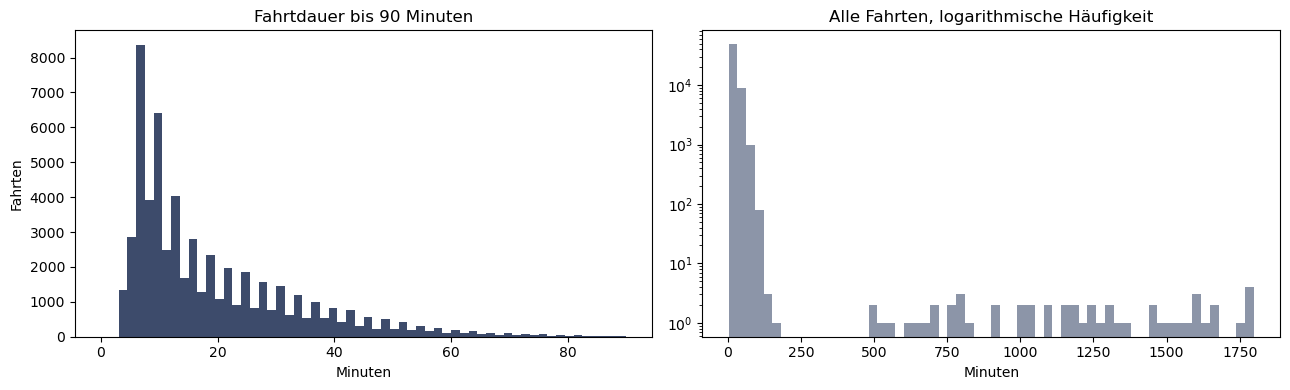

In [4]:
fahrten["dauer_min"] = (fahrten.endzeit - fahrten.startzeit).dt.total_seconds() / 60
echte = fahrten[fahrten.status == "abgeschlossen"]

print(echte.dauer_min.describe().round(1).to_string())
print(f"\nMedian:        {echte.dauer_min.median():.1f} Minuten")
print(f"95%-Quantil:   {echte.dauer_min.quantile(0.95):.1f} Minuten")
print(f"99,9%-Quantil: {echte.dauer_min.quantile(0.999):.1f} Minuten")
print(f"Maximum:       {echte.dauer_min.max():.0f} Minuten "
      f"({echte.dauer_min.max()/60:.1f} Stunden!)")

fig, achsen = plt.subplots(1, 2, figsize=(13, 4))
achsen[0].hist(echte.dauer_min, bins=60, range=(0, 90), color="#3d4b6b")
achsen[0].set_title("Fahrtdauer bis 90 Minuten")
achsen[0].set_xlabel("Minuten"); achsen[0].set_ylabel("Fahrten")
achsen[1].hist(echte.dauer_min, bins=60, color="#8c95a8")
achsen[1].set_yscale("log")
achsen[1].set_title("Alle Fahrten, logarithmische Häufigkeit")
achsen[1].set_xlabel("Minuten")
plt.tight_layout(); plt.show()

Die Verteilung ist **rechtsschief**: viele kurze Fahrten, ein langer dünner Ausläufer.
Das rechte Diagramm — mit logarithmischer Achse, damit die seltenen Fälle überhaupt
sichtbar werden — zeigt einzelne Fahrten von über acht Stunden.

Das sind vermutlich **vergessene Rückgaben**, keine echten Fahrten. Wir merken sie uns
für Phase 3; wegwerfen wollen wir sie hier noch nicht, denn im sechsten Notebook sind
genau sie der interessante Fall.

### 2.4 Erkunden — welche Merkmale hängen mit der Dauer zusammen?

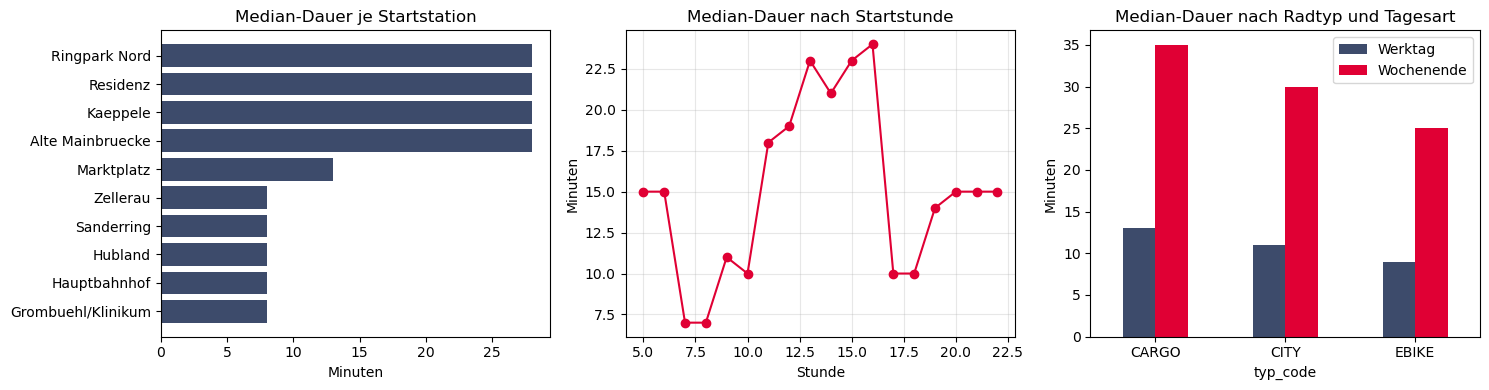

In [5]:
echte = echte.merge(stationen[["station_id", "name"]],
                    left_on="start_station_id", right_on="station_id", how="left")
echte = echte.merge(raeder[["fahrrad_id", "typ_code"]], on="fahrrad_id", how="left")
echte["stunde"] = echte.startzeit.dt.hour
echte["wochentag"] = echte.startzeit.dt.dayofweek        # 0 = Montag
echte["ist_wochenende"] = echte.wochentag >= 5

fig, achsen = plt.subplots(1, 3, figsize=(15, 4))

je_station = echte.groupby("name").dauer_min.median().sort_values()
achsen[0].barh(je_station.index, je_station.values, color="#3d4b6b")
achsen[0].set_title("Median-Dauer je Startstation"); achsen[0].set_xlabel("Minuten")

je_stunde = echte.groupby("stunde").dauer_min.median()
achsen[1].plot(je_stunde.index, je_stunde.values, marker="o", color="#e00034")
achsen[1].set_title("Median-Dauer nach Startstunde")
achsen[1].set_xlabel("Stunde"); achsen[1].set_ylabel("Minuten"); achsen[1].grid(alpha=.3)

je_typ = echte.groupby(["typ_code", "ist_wochenende"]).dauer_min.median().unstack()
je_typ.columns = ["Werktag", "Wochenende"]
je_typ.plot(kind="bar", ax=achsen[2], color=["#3d4b6b", "#e00034"], rot=0)
achsen[2].set_title("Median-Dauer nach Radtyp und Tagesart"); achsen[2].set_ylabel("Minuten")

plt.tight_layout(); plt.show()

**Das ist ein gutes Ergebnis für Phase 2.** Alle drei Bilder zeigen deutliche
Unterschiede — es gibt also etwas zu lernen:

- **Die Startstation trennt am stärksten.** Käppele und Alte Mainbrücke (Ausflugsziele)
  liegen weit über Hauptbahnhof und Zellerau (Pendelwege). Das ist plausibel und damit
  ein glaubwürdiges Merkmal.
- **Die Startstunde trägt einen erkennbaren Tagesgang**, mit kurzen Fahrten zu den
  Pendlerzeiten und längeren am Nachmittag.
- **Wochenende schlägt bei jedem Radtyp durch.**

Wären alle drei Bilder flach gewesen, hätten wir hier abbrechen und in Phase 1
zurückkehren müssen — mit dem Befund, dass die vorhandenen Daten die Frage nicht
beantworten können. **Auch das ist ein legitimes Projektergebnis.**

---

1. Business · 2. Data · **3. Data** · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 3 von 6 — Data Preparation

> **Leitfrage:** Wie wird aus Rohdaten eine Tabelle, mit der ein Verfahren rechnen kann?
>
> **In diesem Notebook heißt das:** Aus 60.000 Fahrtzeilen wird eine Merkmalstabelle. Die wichtigste Entscheidung dabei ist, welche Spalten wir **nicht** verwenden dürfen.

### 3.1 Die Falle: Merkmale, die es zum Vorhersagezeitpunkt nicht gibt

Diese Tabelle enthält zwei Spalten, mit denen man die Fahrtdauer **fast perfekt**
vorhersagen könnte:

| Spalte | Warum sie verlockend ist | Warum sie verboten ist |
|---|---|---|
| `endzeit` | Die Dauer ist Endzeit minus Startzeit | Wer die Endzeit kennt, kennt die Dauer. Beim Entsperren weiß sie niemand. |
| `distanz_km` | Länger gefahren heißt länger unterwegs | Wird während der Fahrt gemessen, steht vorher nicht zur Verfügung |
| `end_station_id` | Ziel und Weg hängen eng zusammen | Das Ziel steht erst am Ende fest |

Man nennt das **Leakage** (Datenlecks): Information aus der Zukunft sickert in die
Merkmale. Modelle mit Leakage sehen im Test glänzend aus und versagen im Betrieb —
die schlimmste aller Fehlerarten, weil sie erst auffällt, wenn es teuer wird.

**Die Prüffrage lautet immer:** *Steht dieser Wert zu dem Zeitpunkt zur Verfügung, an
dem ich die Vorhersage brauche?* Hier ist das der Moment des Entsperrens.

Erlaubt sind damit: Startstation, Startzeit, Radtyp, Wetter (als Prognose), Kalender
(Feiertag, Ferien, Vorlesungszeit, Veranstaltung) und was wir über den Kunden wissen.

### 3.2 Auswählen und bereinigen

In [6]:
roh = fahrten.copy()
vorher = len(roh)

# (1) Nur echte Fahrten - abgebrochene und stornierte Vorgaenge sind keine.
roh = roh[roh.status == "abgeschlossen"]
nach_status = len(roh)

roh = roh[roh.dauer_min <= 480]
nach_ausreisser = len(roh)

# (3) Unplausibel kurze Fahrten: unter 3 Minuten ist keine Fahrt, sondern
#     ein Fehlgriff am Terminal.
roh = roh[roh.dauer_min >= 3]

print(f"Ausgangsmenge              {vorher:>7,d}".replace(",", "."))
print(f"nur abgeschlossene         {nach_status:>7,d}  (-{vorher-nach_status})".replace(",", "."))
print(f"ohne Fahrten über 8 h      {nach_ausreisser:>7,d}  (-{nach_status-nach_ausreisser})".replace(",", "."))
print(f"ohne Fahrten unter 3 Min   {len(roh):>7,d}  (-{nach_ausreisser-len(roh)})".replace(",", "."))
print(f"\nverbleibend: {len(roh)/vorher:.1%} der Ausgangsmenge")

assert len(roh) > 50000, "Es sollten über 50.000 Fahrten übrig bleiben"

Ausgangsmenge               60.124
nur abgeschlossene          58.519  (-1605)
ohne Fahrten über 8 h       58.467  (-52)
ohne Fahrten unter 3 Min    58.467  (-0)

verbleibend: 97.2% der Ausgangsmenge


> **Jede Zeile, die man wegwirft, muss man begründen können.** Wir haben drei Filter
> gesetzt und zusammen rund 5 % der Daten entfernt. Wer 40 % entfernt, modelliert
> nicht mehr den Betrieb, sondern seinen Lieblingsausschnitt daraus.

### 3.3 Merkmale bauen

Jetzt holen wir die Zusatztabellen dazu. Jeder `merge` ist eine bewusste Entscheidung —
und jeder kann Zeilen verlieren, wenn Schlüssel nicht passen. Deshalb prüfen wir nach
jedem Schritt die Zeilenzahl.

In [7]:
daten = roh.copy()
n_start = len(daten)

# --- Zeitmerkmale
daten["stunde"] = daten.startzeit.dt.hour
daten["wochentag"] = daten.startzeit.dt.dayofweek
daten["monat"] = daten.startzeit.dt.month
daten["ist_wochenende"] = (daten.wochentag >= 5).astype(int)
daten["datum"] = daten.startzeit.dt.normalize()

# --- Radtyp
daten = daten.merge(raeder[["fahrrad_id", "typ_code"]], on="fahrrad_id", how="left")

# --- Startstation (Name und Kapazität)
daten = daten.merge(stationen[["station_id", "name", "kapazitaet"]],
                    left_on="start_station_id", right_on="station_id", how="left")
daten = daten.rename(columns={"name": "startstation"})

daten = daten.merge(wetter[["datum", "temp_mittel_c", "niederschlag_mm"]],
                    on="datum", how="left")

# --- Kalender: Feiertag, Schulferien, Vorlesungszeit, Veranstaltung
feiertage = pd.read_csv(BASIS + "feiertage.csv", parse_dates=["datum"])
daten["ist_feiertag"] = daten.datum.isin(set(feiertage.datum)).astype(int)

def tage_aus_zeitraeumen(datei):
    """Aus 'von'/'bis'-Zeilen eine Menge einzelner Tage machen."""
    z = pd.read_csv(BASIS + datei, parse_dates=["von", "bis"])
    tage = set()
    for _, r in z.iterrows():
        tage.update(pd.date_range(r.von, r.bis, freq="D"))
    return tage

daten["ist_ferien"] = daten.datum.isin(tage_aus_zeitraeumen("schulferien.csv")).astype(int)
daten["ist_vorlesungszeit"] = daten.datum.isin(tage_aus_zeitraeumen("semesterzeiten.csv")).astype(int)
daten["ist_veranstaltung"] = daten.datum.isin(tage_aus_zeitraeumen("veranstaltungen.csv")).astype(int)

# --- Kundschaft: Tarif und Alter
daten = daten.merge(kunden[["kunde_id", "tarif_code", "geburtsjahr"]], on="kunde_id", how="left")
daten["alter"] = daten.startzeit.dt.year - daten.geburtsjahr

print(f"Zeilen vorher: {n_start}, nachher: {len(daten)}")
assert len(daten) == n_start, "Ein merge hat Zeilen verloren oder vervielfacht!"
print("Fehlende Werte nach dem Zusammenführen:")
print(daten[["temp_mittel_c", "niederschlag_mm", "tarif_code", "typ_code"]].isna().sum().to_string())

Zeilen vorher: 58467, nachher: 58467
Fehlende Werte nach dem Zusammenführen:
temp_mittel_c      0
niederschlag_mm    0
tarif_code         0
typ_code           0


Das `assert` nach den `merge`-Aufrufen ist kein Zierrat. Ein `merge` mit einem Schlüssel,
der auf der rechten Seite mehrfach vorkommt, vervielfacht stillschweigend Zeilen — der
häufigste und am schwersten zu findende Fehler in dieser Phase. Wer die Zeilenzahl nicht
prüft, merkt es erst, wenn die Ergebnisse unerklärlich gut sind.

### 3.4 Kodieren und aufteilen

In [8]:
from sklearn.model_selection import train_test_split

kategorial = ["typ_code", "startstation", "tarif_code"]
numerisch = ["stunde", "wochentag", "monat", "ist_wochenende", "kapazitaet",
             "temp_mittel_c", "niederschlag_mm", "ist_feiertag", "ist_ferien",
             "ist_vorlesungszeit", "ist_veranstaltung", "alter"]

dummies = pd.get_dummies(daten[kategorial], prefix=kategorial).astype(int)
X = pd.concat([daten[numerisch].reset_index(drop=True), dummies.reset_index(drop=True)], axis=1)
y = daten["dauer_min"].reset_index(drop=True)

print(f"Merkmalsmatrix: {X.shape[0]} Zeilen × {X.shape[1]} Spalten")
print(f"davon aus kategorialen Merkmalen: {dummies.shape[1]}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"\nTraining: {len(X_train):>6,d} Fahrten".replace(",", "."))
print(f"Test:     {len(X_test):>6,d} Fahrten".replace(",", "."))
print(f"Mittlere Dauer  Training {y_train.mean():.1f} Min | Test {y_test.mean():.1f} Min")

Merkmalsmatrix: 58467 Zeilen × 29 Spalten
davon aus kategorialen Merkmalen: 17

Training: 43.850 Fahrten
Test:     14.617 Fahrten
Mittlere Dauer  Training 19.0 Min | Test 19.2 Min


> **Warum hier zufällig geteilt wird und im vierten Notebook nicht.**
> Wir sagen *keine Zukunft* vorher, sondern eine Eigenschaft einer einzelnen Fahrt.
> Fahrten sind untereinander austauschbar, ein zufälliger Schnitt ist also fair.
> Sobald eine **Zeitreihe** prognostiziert wird, ist ein zufälliger Schnitt ein
> schwerer Fehler — dann darf das Modell nichts aus der Zukunft gesehen haben.
> Genau das ist Thema in Notebook 4.

---

1. Business · 2. Data · 3. Data · **4. Modeling** · 5. Evaluation · 6. Deployment

# Phase 4 von 6 — Modeling

> **Leitfrage:** Welches Verfahren, welche Einstellungen, wie geprüft?
>
> **In diesem Notebook heißt das:** Drei Modelle, vom einfachsten zum stärksten — und ein Nullmodell als Maßstab.

### 4.1 Zuerst das Nullmodell

Bevor irgendein Verfahren gelobt wird, braucht es einen **Maßstab**: Wie gut wäre man,
wenn man immer den Mittelwert vorhersagt? Jedes Modell muss diesen Wert schlagen — sonst
hat es nichts gelernt, und aller Aufwand war umsonst.

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def bewerten(name, y_wahr, y_schaetzung):
    mae = mean_absolute_error(y_wahr, y_schaetzung)
    rmse = float(np.sqrt(mean_squared_error(y_wahr, y_schaetzung)))
    r2 = r2_score(y_wahr, y_schaetzung)
    return {"Modell": name, "MAE (Min)": round(mae, 2),
            "RMSE (Min)": round(rmse, 2), "R²": round(r2, 3)}

ergebnisse = []
null_schaetzung = np.full(len(y_test), y_train.mean())
ergebnisse.append(bewerten("Nullmodell (immer der Mittelwert)", y_test, null_schaetzung))
print(pd.DataFrame(ergebnisse).to_string(index=False))

                           Modell  MAE (Min)  RMSE (Min)   R²
Nullmodell (immer der Mittelwert)      11.75       15.13 -0.0


### 4.2 Lineare Regression — das durchschaubarste Modell

In [10]:
from sklearn.linear_model import LinearRegression

linear = LinearRegression()
linear.fit(X_train, y_train)
ergebnisse.append(bewerten("Lineare Regression", y_test, linear.predict(X_test)))
print(pd.DataFrame(ergebnisse).to_string(index=False))

koeffizienten = pd.Series(linear.coef_, index=X.columns).sort_values()
print("\nDie fünf stärksten Verlängerer und Verkürzer (Minuten je Einheit):")
print(pd.concat([koeffizienten.head(5), koeffizienten.tail(5)]).round(2).to_string())

                           Modell  MAE (Min)  RMSE (Min)     R²
Nullmodell (immer der Mittelwert)      11.75       15.13 -0.000
               Lineare Regression       6.14        8.97  0.648

Die fünf stärksten Verlängerer und Verkürzer (Minuten je Einheit):
startstation_Zellerau             -10.15
startstation_Grombuehl/Klinikum    -5.32
typ_code_EBIKE                     -3.47
startstation_Sanderring            -3.43
startstation_Marktplatz            -3.15
startstation_Hauptbahnhof           4.10
startstation_Alte Mainbruecke       5.76
ist_feiertag                        7.68
ist_wochenende                      8.61
startstation_Residenz               9.10


Die Koeffizienten sind der große Vorteil dieses Verfahrens: **man kann sie vorlesen.**
„Eine Fahrt ab Käppele dauert im Mittel *x* Minuten länger als eine sonst gleiche Fahrt.“
Das versteht auch, wer nie etwas von Regression gehört hat — und genau das braucht man,
um ein Modell in einer Fachabteilung durchzusetzen.

### 4.3 Entscheidungsbaum und Random Forest

In [11]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

baum = DecisionTreeRegressor(max_depth=8, min_samples_leaf=50, random_state=42)
baum.fit(X_train, y_train)
ergebnisse.append(bewerten("Entscheidungsbaum (Tiefe 8)", y_test, baum.predict(X_test)))

wald = RandomForestRegressor(n_estimators=200, max_depth=16, min_samples_leaf=20,
                             random_state=42, n_jobs=-1)
wald.fit(X_train, y_train)
ergebnisse.append(bewerten("Random Forest (200 Bäume)", y_test, wald.predict(X_test)))

tabelle = pd.DataFrame(ergebnisse)
print(tabelle.to_string(index=False))

                           Modell  MAE (Min)  RMSE (Min)     R²
Nullmodell (immer der Mittelwert)      11.75       15.13 -0.000
               Lineare Regression       6.14        8.97  0.648
      Entscheidungsbaum (Tiefe 8)       5.03        7.85  0.731
        Random Forest (200 Bäume)       4.75        7.48  0.755


> **Warum drei Modelle statt gleich des besten?** Weil „das beste“ erst im Vergleich
> entsteht. Ein Random Forest allein sagt nichts darüber, ob die Aufgabe schwer war oder
> das Modell gut ist. Der Abstand zum Nullmodell zeigt, wieviel überhaupt lernbar war;
> der Abstand zwischen linear und Forest zeigt, wieviel davon nichtlinear ist.

---

1. Business · 2. Data · 3. Data · 4. Modeling · **5. Evaluation** · 6. Deployment

# Phase 5 von 6 — Evaluation

> **Leitfrage:** Ist das Modell gut genug für die Geschäftsfrage aus Phase 1?
>
> **In diesem Notebook heißt das:** Die Modellgüte kennen wir jetzt. Die eigentliche Frage lautet: reicht sie für die Preisanzeige aus Phase 1?

### 5.1 Technische Güte im Vergleich

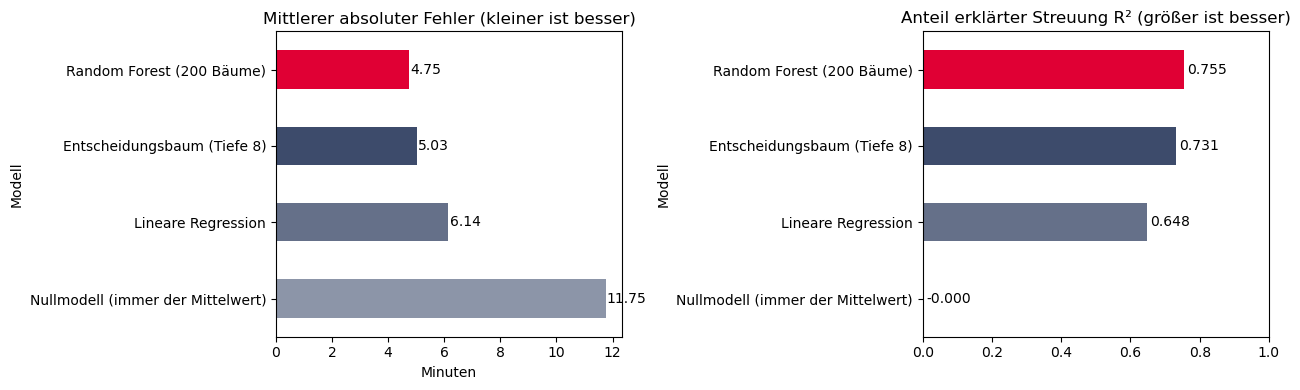

Bestes Modell: Random Forest (200 Bäume)  mit MAE 4.75 Minuten
Verbesserung gegenüber dem Nullmodell: 59.6%


In [12]:
tabelle = pd.DataFrame(ergebnisse).set_index("Modell")
fig, achsen = plt.subplots(1, 2, figsize=(13, 4))
farben = ["#8c95a8", "#657089", "#3d4b6b", "#e00034"]

tabelle["MAE (Min)"].plot(kind="barh", ax=achsen[0], color=farben)
achsen[0].set_title("Mittlerer absoluter Fehler (kleiner ist besser)")
achsen[0].set_xlabel("Minuten")
for i, v in enumerate(tabelle["MAE (Min)"]):
    achsen[0].text(v + 0.05, i, f"{v:.2f}", va="center")

tabelle["R²"].plot(kind="barh", ax=achsen[1], color=farben)
achsen[1].set_title("Anteil erklärter Streuung R² (größer ist besser)")
achsen[1].set_xlim(0, 1)
for i, v in enumerate(tabelle["R²"]):
    achsen[1].text(v + 0.01, i, f"{v:.3f}", va="center")
plt.tight_layout(); plt.show()

bestes = tabelle["MAE (Min)"].idxmin()
bester_mae = tabelle.loc[bestes, "MAE (Min)"]
print(f"Bestes Modell: {bestes}  mit MAE {bester_mae:.2f} Minuten")
print(f"Verbesserung gegenüber dem Nullmodell: "
      f"{(1 - bester_mae / tabelle['MAE (Min)'].iloc[0]):.1%}")

### 5.2 Die entscheidende Rechnung: reicht das für die Preisanzeige?

In [13]:
schaetzung = wald.predict(X_test)
pruef = pd.DataFrame({"dauer_wahr": y_test.values, "dauer_geschaetzt": schaetzung})
pruef["typ_code"] = daten.loc[y_test.index, "typ_code"].values
pruef["fehler_min"] = (pruef.dauer_geschaetzt - pruef.dauer_wahr).abs()

minutenpreis = preise.set_index("typ_code")["preis_pro_minute_eur"]
pruef["fehler_eur"] = pruef.fehler_min * pruef.typ_code.map(minutenpreis)

je_typ = pruef.groupby("typ_code").agg(
    fahrten=("fehler_eur", "size"),
    mae_minuten=("fehler_min", "mean"),
    mae_euro=("fehler_eur", "mean"),
    anteil_unter_50ct=("fehler_eur", lambda s: (s < 0.50).mean()),
).round(3)
je_typ["Kriterium erfüllt"] = np.where(je_typ.mae_euro < 0.50, "ja", "NEIN")
print(je_typ.to_string())

print(f"\nÜber alle Radtypen: {pruef.fehler_eur.mean():.2f} EUR mittlerer Preisfehler")
print(f"Anteil der Fahrten mit unter 50 Cent Abweichung: {(pruef.fehler_eur < 0.50).mean():.1%}")

          fahrten  mae_minuten  mae_euro  anteil_unter_50ct Kriterium erfüllt
typ_code                                                                     
CARGO        1416        5.807     2.904              0.175              NEIN
CITY         7880        4.938     0.494              0.684                ja
EBIKE        5321        4.184     1.046              0.445              NEIN

Über alle Radtypen: 0.93 EUR mittlerer Preisfehler
Anteil der Fahrten mit unter 50 Cent Abweichung: 54.8%


### 5.3 Das Urteil

**Und hier zeigt sich, warum Phase 1 vor Phase 5 kommt.** Über alle Radtypen gemittelt
liegt der Preisfehler bei rund 0,93 € — das Kriterium wäre klar gerissen, das Projekt
gescheitert. Nach Radtyp getrennt sieht es anders aus:

- Beim **CITY-Rad** hält das Modell das Kriterium (0,49 € gegen 0,50 € Schwelle). Bei
  0,10 €/Minute darf man sich knapp fünf Minuten irren — und genau so gut ist das Modell.
- Beim **EBIKE** (1,05 €) und erst recht beim **CARGO-Rad** (2,90 €) reißt es das
  Kriterium deutlich. Der Grund ist keine Schwäche des Modells: Der Schätzfehler in
  Minuten ist dort sogar **kleiner** als beim CITY-Rad. Er schlägt nur zweieinhalb- bis
  fünfmal so stark auf den Preis durch, weil die Minute mehr kostet.

**Das ist der lehrreichste Befund dieses Notebooks.** Dieselbe Modellgüte ist für ein
Produkt ausreichend und für ein anderes unbrauchbar — und der Unterschied liegt nicht in
der Statistik, sondern im Preisblatt. Wer nur auf MAE und R² schaut, sieht das nie.

Ein Mittelwert über alle Radtypen hätte den Befund in beide Richtungen **verdeckt**:
Er hätte das brauchbare CITY-Modell mit begraben. Genau deshalb gehört in die Evaluation
immer die Frage: *Für wen gilt das Ergebnis — und für wen nicht?*

### 5.4 Wo irrt das Modell? — Fehleranalyse

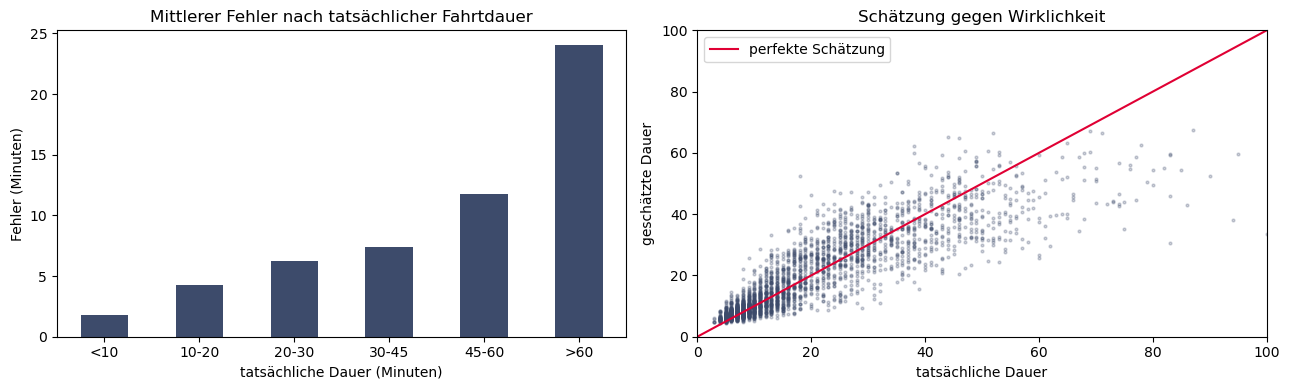

In [14]:
pruef["dauer_gruppe"] = pd.cut(pruef.dauer_wahr, [0, 10, 20, 30, 45, 60, 480],
                               labels=["<10", "10-20", "20-30", "30-45", "45-60", ">60"])
fig, achsen = plt.subplots(1, 2, figsize=(13, 4))

je_gruppe = pruef.groupby("dauer_gruppe", observed=True).fehler_min.mean()
je_gruppe.plot(kind="bar", ax=achsen[0], color="#3d4b6b", rot=0)
achsen[0].set_title("Mittlerer Fehler nach tatsächlicher Fahrtdauer")
achsen[0].set_xlabel("tatsächliche Dauer (Minuten)"); achsen[0].set_ylabel("Fehler (Minuten)")

stichprobe = pruef.sample(3000, random_state=42)
achsen[1].scatter(stichprobe.dauer_wahr, stichprobe.dauer_geschaetzt, s=4, alpha=.25, color="#3d4b6b")
grenze = 100
achsen[1].plot([0, grenze], [0, grenze], color="#e00034", lw=1.5, label="perfekte Schätzung")
achsen[1].set_xlim(0, grenze); achsen[1].set_ylim(0, grenze)
achsen[1].set_xlabel("tatsächliche Dauer"); achsen[1].set_ylabel("geschätzte Dauer")
achsen[1].set_title("Schätzung gegen Wirklichkeit"); achsen[1].legend()
plt.tight_layout(); plt.show()

Die beiden Bilder zeigen dasselbe aus zwei Richtungen und sind der ehrlichste Teil
dieses Notebooks:

**Das Modell schätzt lange Fahrten systematisch zu kurz.** Die Punktwolke rechts biegt
unter der roten Linie ab: Ab etwa 40 Minuten liegt die Schätzung fast immer darunter.

Das ist kein Programmierfehler, sondern eine **Eigenschaft der Aufgabe**. Was eine Fahrt
lang macht — ein Umweg, eine Pause, ein spontaner Abstecher — steht in keiner unserer
Spalten. Das Modell kann nur den Mittelwert der jeweiligen Situation treffen, und der
liegt bei einer rechtsschiefen Verteilung unter den Ausreißern.

> **Für die Preisanzeige heißt das:** Die Schätzung ist im Mittel zu niedrig. Der Kunde
> bekommt eher eine positive Überraschung angezeigt und zahlt dann mehr — die für das
> Vertrauen ungünstigere Richtung. Das gehört ins Deployment.

### 5.5 Rücksprung oder weiter?

CRISP-DM verlangt an dieser Stelle eine **ausdrückliche Entscheidung**. Unsere lautet:

| Radtyp | Entscheidung | Begründung |
|---|---|---|
| **CITY** | **Freigabe** | Kriterium erfüllt (0,49 € < 0,50 €). Betrifft rund 55 % aller Fahrten — der Nutzen ist real. |
| **EBIKE** | **Rücksprung** | 1,05 € — mehr als doppelt so hoch wie erlaubt |
| **CARGO** | **Rücksprung** | 2,90 € — die Punktschätzung ist hier die falsche Zusage |

Eine **Teilfreigabe** ist ein völlig normales Projektergebnis und in CRISP-DM
ausdrücklich vorgesehen. Was sie erfordert, ist Disziplin bei der Auslieferung: Das
Modell darf für EBIKE und CARGO **nicht** aufgerufen werden, und diese Einschränkung
muss im Modellpaket stehen, nicht in einer E-Mail.

Für EBIKE und CARGO geht es zurück auf Phase 1 — das ist der Pfeil von 5 nach 1.

---

1. Business · 2. Data · 3. Data · 4. Modeling · 5. Evaluation · **6. Deployment**

# Phase 6 von 6 — Deployment

> **Leitfrage:** Wie kommt das Modell in den Betrieb — und was passiert danach?
>
> **In diesem Notebook heißt das:** Ein Modell im Notebook nützt niemandem. Es muss in den Entsperr-Dialog.

### 6.1 Das Modell haltbar machen

Ein trainiertes Modell lebt zunächst nur im Arbeitsspeicher. Für den Betrieb muss es
gespeichert und zusammen mit **allem, was zu seiner Anwendung nötig ist**, ausgeliefert
werden: die Liste und Reihenfolge der Merkmalsspalten gehört dazu — eine vertauschte
Spalte macht jede Vorhersage still und leise falsch.

In [15]:
import joblib, json, datetime

paket = {
    "modell": wald,
    "merkmalsspalten": list(X.columns),
    "trainiert_am": datetime.date.today().isoformat(),
    "trainingszeitraum": [str(daten.startzeit.min().date()), str(daten.startzeit.max().date())],
    "mae_test_minuten": float(mean_absolute_error(y_test, schaetzung)),
    # Die Einschraenkung gehoert INS PAKET, nicht in eine E-Mail. Wer das
    # Modell laedt, sieht sofort, wofuer es freigegeben ist.
    "gilt_fuer": ["CITY"],
    "nicht_freigegeben_fuer": ["EBIKE", "CARGO"],
    "erfolgskriterium": "mittlerer Preisfehler unter 0,50 EUR",
}
joblib.dump(paket, "fahrtdauer_modell.joblib")
print("gespeichert:", round(os.path.getsize("fahrtdauer_modell.joblib") / 1024 / 1024, 1), "MB")
print(json.dumps({k: v for k, v in paket.items() if k != "modell"}, indent=2, ensure_ascii=False))

gespeichert: 27.6 MB
{
  "merkmalsspalten": [
    "stunde",
    "wochentag",
    "monat",
    "ist_wochenende",
    "kapazitaet",
    "temp_mittel_c",
    "niederschlag_mm",
    "ist_feiertag",
    "ist_ferien",
    "ist_vorlesungszeit",
    "ist_veranstaltung",
    "alter",
    "typ_code_CARGO",
    "typ_code_CITY",
    "typ_code_EBIKE",
    "startstation_Alte Mainbruecke",
    "startstation_Grombuehl/Klinikum",
    "startstation_Hauptbahnhof",
    "startstation_Hubland",
    "startstation_Kaeppele",
    "startstation_Marktplatz",
    "startstation_Residenz",
    "startstation_Ringpark Nord",
    "startstation_Sanderring",
    "startstation_Zellerau",
    "tarif_code_BASIS",
    "tarif_code_OEPNV",
    "tarif_code_PREMIUM",
    "tarif_code_STUDENT"
  ],
  "trainiert_am": "2026-08-31",
  "trainingszeitraum": [
    "2023-09-01",
    "2026-08-24"
  ],
  "mae_test_minuten": 4.747658387546647,
  "gilt_fuer": [
    "CITY"
  ],
  "nicht_freigegeben_fuer": [
    "EBIKE",
    "CARGO"
  ],
  "e

### 6.2 Die Funktion, die im Entsperr-Dialog aufgerufen wird

In [16]:
def preis_schaetzen(startstation, typ_code, zeitpunkt, tarif_code="BASIS",
                    temperatur=18.0, niederschlag=0.0, alter=35,
                    feiertag=0, ferien=0, vorlesungszeit=1, veranstaltung=0):
    """Schätzt Dauer und Preis einer Fahrt - genau die Größen, die der Dialog anzeigt.

    Nimmt nur Angaben entgegen, die beim Entsperren wirklich vorliegen.
    """
    kapazitaet = int(stationen.loc[stationen.name == startstation, "kapazitaet"].iloc[0])
    zeile = {sp: 0 for sp in paket["merkmalsspalten"]}
    zeile.update({
        "stunde": zeitpunkt.hour, "wochentag": zeitpunkt.weekday(), "monat": zeitpunkt.month,
        "ist_wochenende": int(zeitpunkt.weekday() >= 5), "kapazitaet": kapazitaet,
        "temp_mittel_c": temperatur, "niederschlag_mm": niederschlag,
        "ist_feiertag": feiertag, "ist_ferien": ferien,
        "ist_vorlesungszeit": vorlesungszeit, "ist_veranstaltung": veranstaltung,
        "alter": alter,
    })
    for spalte, wert in [("typ_code", typ_code), ("startstation", startstation),
                         ("tarif_code", tarif_code)]:
        schluessel = f"{spalte}_{wert}"
        if schluessel in zeile:
            zeile[schluessel] = 1

    X_neu = pd.DataFrame([zeile])[paket["merkmalsspalten"]]
    dauer = float(paket["modell"].predict(X_neu)[0])

    p = preise.set_index("typ_code").loc[typ_code]
    betrag = min(p.startgebuehr_eur + dauer * p.preis_pro_minute_eur, p.tageshoechstpreis_eur)
    return round(dauer, 1), round(betrag, 2)


import datetime as dt
beispiele = [
    ("Hauptbahnhof",     "CITY",  dt.datetime(2026, 9, 15, 8, 10), "OEPNV"),
    ("Kaeppele",         "EBIKE", dt.datetime(2026, 9, 20, 15, 0), "BASIS"),
    ("Hubland",          "CITY",  dt.datetime(2026, 9, 15, 14, 0), "STUDENT"),
]
print(f"{'Station':<16s}{'Typ':<7s}{'Zeitpunkt':<18s}{'Dauer':>8s}{'Preis':>9s}")
print("-" * 58)
for station, typ, wann, tarif in beispiele:
    dauer, betrag = preis_schaetzen(station, typ, wann, tarif)
    print(f"{station:<16s}{typ:<7s}{wann.strftime('%a %d.%m. %H:%M'):<18s}"
          f"{dauer:>6.1f} Min{betrag:>8.2f} €")

Station         Typ    Zeitpunkt            Dauer    Preis
----------------------------------------------------------
Hauptbahnhof    CITY   Tue 15.09. 08:10     7.4 Min    0.84 €
Kaeppele        EBIKE  Sun 20.09. 15:00    45.3 Min   12.33 €


Hubland         CITY   Tue 15.09. 14:00    11.0 Min    1.20 €


### 6.3 Was nach der Auslieferung passieren muss

Ein Modell in Betrieb ist kein fertiges Projekt, sondern ein laufendes. CRISP-DM nennt
für diese Phase vier Ergebnisse; hier sind sie für unseren Fall ausformuliert:

**1. Deployment Plan — wie es in den Betrieb kommt**
Die Funktion oben wird als kleiner Dienst hinter der App bereitgestellt. Wichtig ist die
Reihenfolge: erst im **Schattenbetrieb** mitrechnen, ohne dem Kunden etwas anzuzeigen,
und die Schätzungen mit den tatsächlichen Dauern vergleichen. Erst wenn das Bild dem
hier gemessenen entspricht, wird die Anzeige eingeschaltet — und zunächst nur für CITY
und EBIKE.

**2. Monitoring — woran man merkt, dass es nicht mehr stimmt**

| Wache | Schwelle | Reaktion |
|---|---|---|
| **mittlerer Preisfehler, 30 Tage, nur CITY** | über 0,55 € | Anzeige abschalten |
| | 0,45 bis 0,55 € | beobachten, nicht handeln |
| Anteil der Fahrten mit Typ CITY | fällt unter 40 % | die Freigabe deckt immer weniger ab — Projekt neu bewerten |
| Verteilung der Startstationen | neue Station taucht auf | Modell kennt sie nicht — nachtrainieren |
| Tarifblatt | Minutenpreis ändert sich | Erfolgskriterium neu rechnen — die erlaubte Minuten-Toleranz hängt daran |

Die erste Wache misst **genau die Größe aus dem Erfolgskriterium von Phase 1**, und zwar
im selben Zuschnitt wie die Freigabe. Zwei verschiedene Maße für dieselbe Frage sind eine
Einladung zum Rosinenpicken. Das gelbe Band verhindert, dass die Anzeige bei einem Wert,
der um die Schwelle pendelt, täglich an- und ausgeht.

Der dritte Punkt ist der praktisch wichtigste: **Sobald VeloCity eine elfte Station
eröffnet, hat das Modell für sie keine Spalte.** Es wird trotzdem eine Zahl liefern —
eine falsche. So etwas fällt ohne Überwachung monatelang nicht auf.

**3. Wartung — der Kreislauf schließt sich**
Ein Nachtraining vierteljährlich, außerdem sofort bei jeder Tarifänderung oder neuen
Station. Jedes Nachtraining beginnt wieder bei Phase 1: *Ist die Frage noch dieselbe?*

**4. Der Abschlussbericht** hält fest, was das Modell **nicht** kann — die CARGO-Lücke
und die systematische Unterschätzung langer Fahrten. Ein Bericht, der nur die guten
Zahlen nennt, ist keine Dokumentation, sondern Werbung.

In [17]:
# Der Schattenbetrieb, im Kleinen: die letzten 30 Tage so behandeln, als
# waeren sie unbekannt, und nachrechnen, was der Kunde angezeigt bekommen haette.
#
# WICHTIG: nur fuer CITY. Die Ueberwachung muss denselben Zuschnitt haben wie
# die Freigabe - eine Ampel ueber alle Radtypen wuerde ein Modell rot faerben,
# das fuer seinen freigegebenen Bereich einwandfrei arbeitet.
letzter_tag = daten.startzeit.max().normalize()
fenster = daten[(daten.startzeit >= letzter_tag - pd.Timedelta(days=30))
                & (daten.typ_code.isin(paket["gilt_fuer"]))]
X_fenster = X.loc[fenster.index]
y_fenster = y.loc[fenster.index]

vorhersage = wald.predict(X_fenster)
fehler_eur = (np.abs(vorhersage - y_fenster.values)
              * fenster.typ_code.map(minutenpreis).values)

anzahl = f"{len(fenster):,d}".replace(",", ".")
print(f"Schattenbetrieb, nur {'/'.join(paket['gilt_fuer'])}, letzte 30 Tage: {anzahl} Fahrten")
print(f"   MAE                                 {mean_absolute_error(y_fenster, vorhersage):.2f} Minuten")
print(f"   mittlerer Preisfehler               {fehler_eur.mean():.3f} EUR")
print(f"   Anteil unter 50 Cent Abweichung     {(fehler_eur < 0.50).mean():.1%}")

# Die Ampel misst GENAU die Groesse aus dem Erfolgskriterium von Phase 1 -
# nicht irgendeine andere. Zwei Masse fuer dieselbe Frage sind eine Einladung
# zum Rosinenpicken.
#
# Das gelbe Band ist Absicht: eine einzelne Schwelle flackert. Ein Wert, der
# um 0,50 herum pendelt, wuerde die Anzeige taeglich ein- und ausschalten.
gemessen = fehler_eur.mean()
if gemessen < 0.45:
    ampel = "GRÜN  - Anzeige einschalten"
elif gemessen <= 0.55:
    ampel = "GELB  - im Schattenbetrieb weiterlaufen lassen, noch nicht anzeigen"
else:
    ampel = "ROT   - nicht einschalten, Ursache suchen"
print(f"\n   Kriterium aus Phase 1: mittlerer Preisfehler unter 0,50 EUR")
print(f"   Ampel: {ampel}")

Schattenbetrieb, nur CITY, letzte 30 Tage: 1.260 Fahrten
   MAE                                 5.02 Minuten
   mittlerer Preisfehler               0.502 EUR
   Anteil unter 50 Cent Abweichung     69.0%

   Kriterium aus Phase 1: mittlerer Preisfehler unter 0,50 EUR
   Ampel: GELB  - im Schattenbetrieb weiterlaufen lassen, noch nicht anzeigen


### 6.4 Der Testwert war optimistisch — und das ist der Normalfall

Vergleichen Sie zwei Zahlen aus diesem Notebook:

| | mittlerer Preisfehler CITY |
|---|---|
| Testmenge (Phase 5) | **0,494 €** — Kriterium erfüllt |
| Schattenbetrieb, letzte 30 Tage | **0,502 €** — Kriterium knapp gerissen |

Der Unterschied ist klein, aber er zeigt in eine Richtung, die man kennen muss: **Die
Testmenge ist fast immer optimistischer als der Betrieb.** Gründe dafür gibt es mehrere,
und alle treffen hier zu:

1. Die Testmenge ist ein **zufälliger Schnitt durch drei Jahre**. Der Schattenbetrieb
   sind die letzten 30 Tage — eine einzige Jahreszeit, mit ihrem eigenen Wetter.
2. Wir haben das Modell **mehrfach angesehen**, bevor wir es bewertet haben (drei
   Verfahren verglichen). Jeder Blick auf die Testmenge nutzt sie ein Stück ab.
3. Im Betrieb kommen Fälle vor, die im Training fehlten — neue Kundschaft, ein Feiertag,
   der im Trainingszeitraum anders lag.

**Deshalb steht die Ampel auf Gelb und nicht auf Grün.** Ein Modell, das im Test genau
auf der Schwelle liegt, ist im Betrieb darunter. Die richtige Reaktion ist nicht,
die Schwelle zu senken, sondern weiter im Schattenbetrieb zu messen — und in der
Zwischenzeit an Punkt 1 der Liste „was eine zweite Runde anders machen würde“ zu
arbeiten.

---

# Der Kreislauf schließt sich

**Was dieses Notebook gezeigt hat**

| Phase | Ergebnis |
|---|---|
| 1 Business Understanding | Aus „Preis vorher anzeigen“ wurde ein messbares Kriterium: Preisfehler unter 50 Cent — und daraus je Radtyp eine erlaubte Minuten-Toleranz |
| 2 Data Understanding | Die Daten tragen die Frage: Station, Stunde und Tagesart trennen deutlich. Zwei Qualitätsbefunde: 42 % ohne Distanz, 2,7 % keine echten Fahrten |
| 3 Data Preparation | Leakage vermieden (Endzeit, Distanz, Zielstation gesperrt), drei begründete Filter, Wetter und Kalender angejoint, Zeilenzahl nach jedem Schritt geprüft |
| 4 Modeling | Nullmodell als Maßstab, dann linear, Baum, Random Forest |
| 5 Evaluation | Über alle Räder gemittelt **gerissen** (0,93 €) — nach Radtyp getrennt besteht CITY (0,49 €), EBIKE und CARGO fallen durch. Lange Fahrten werden systematisch unterschätzt |
| 6 Deployment | Modell mit Merkmalsliste gespeichert, Schätzfunktion gebaut, Schattenbetrieb gerechnet, Überwachung und Nachtraining festgelegt |

**Was eine zweite Runde anders machen würde**

Das ist die Frage, mit der CRISP-DM steht und fällt — und die in Lehrbeispielen fast
immer fehlt:

1. **Zurück zu Phase 1:** Für EBIKE und CARGO ist die Punktschätzung die falsche
   Zusage. Eine **Spanne** („zwischen 4 und 9 €“) wäre ehrlicher und erfüllbar. Das
   ändert die Geschäftsfrage — und damit das Verfahren: gefragt wären dann Quantile,
   nicht Mittelwerte.
2. **Zurück zu Phase 2:** Was eine Fahrt lang macht, steht nicht in den Daten. Ein
   Merkmal „Wetterumschwung während der Fahrt“ oder „Steigungsprofil zwischen den
   Stationen“ könnte den Ausläufer erklären. Beides müsste erst beschafft werden.
3. **Zurück zu Phase 3:** Die Zielgröße ist rechtsschief. Ein Modell auf dem
   **Logarithmus** der Dauer trifft solche Verteilungen oft besser — eine Änderung von
   einer Zeile mit möglicherweise großer Wirkung.

**Weiter geht es mit Notebook 2 — Klassifikation:** Dort ist die Zielgröße keine Zahl
mehr, sondern eine Entscheidung: *Braucht dieses Rad bald Wartung, ja oder nein?* Und
dort werden die beiden Fehlerarten — Fehlalarm gegen verpassten Alarm — unterschiedlich
teuer sein.